# Alignment Visualizations

### Imports

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 1

from alignment_evaluation import *
import shutil

# import matplotlib
# matplotlib.use("pgf")
# matplotlib.rcParams.update({
#     "pgf.texsystem": "pdflatex",
#     'font.family': 'serif',
#     'text.usetex': True,
#     'pgf.rcfonts': False,
# })

import seaborn as sns
sns.set(rc={'figure.figsize':(11,4)})
import pandas as pd
import re
import json
from ipywidgets import interactive, interact, fixed, interact_manual, SelectMultiple
from ipywidgets import *
from IPython.display import display

import ipywidgets as widgets

## Parameters

In [2]:
num_populations = 8

feature_extractors = ["maximum_curvature"]
score_functions = ["hamming_distance", "hamming_dist_subsampled"]
alignment_methods = ["id", "leftmost_edge", "huang_normalization", "huang_fingertip", "huang_leftmost", "miura_matching", "centre_of_mass"]
sides_model = ["left", "right"]
sides_probe = ["left", "right", "as_model"]
fingers_model = ["thumb", "index", "middle", "little", "ring"]
fingers_probe = ["thumb", "index", "middle", "little", "ring", "as_model"]
camera_model = [1, 2]
camera_probe = [1, 2, "as_model"]



## Single Tab Widget

In [3]:
class Selector(widgets.GridBox):
    
    idx = {
        "color_picker": 0,
        "title": 1,
        "feature_extractor": 2,
        "alignment": 3,
        "id_m": 4,
        "id_p": 5,
        "side_m": 6,
        "side_p": 7,
        "finger_m": 8,
        "finger_p": 9,
        "trial_m": 10,
        "trial_p": 11,
        "camera_m": 12,
        "camera_p": 13
    }
    
    def __init__(self):
        
        color_picker = widgets.ColorPicker(
            concise=True,
            description='Color:',
            value='#efefef',
        )
        
        title = widgets.Text(
            value='',
            placeholder='Describe your distribution',
            description='Title :',
            disabled=False
        )
        
        feature_extractor = widgets.Select(
            options=feature_extractors,
            value=feature_extractors[0],
            # rows=10,
            description='Feat. Extr:',
            disabled=False
        )
        
        alignment_method = widgets.Select(
            options=alignment_methods,
            value=alignment_methods[0],
            # rows=10,
            description='Align. Mtd:',
            disabled=False
        )

        sides_m = widgets.SelectMultiple(
            options=sides_model,
            value=sides_model,
            # rows=10,
            description='Sides M:',
            disabled=False
        )
    
        sides_p = widgets.SelectMultiple(
            options=sides_probe,
            value=sides_probe[-1:],
            # rows=10,
            description='Sides P:',
            disabled=False
        )
        
        fingers_m = widgets.SelectMultiple(
            options=fingers_model,
            value=fingers_model,
            # rows=10,
            description='Fingers M:',
            disabled=False
        )
        fingers_p = widgets.SelectMultiple(
            options=fingers_probe,
            value=fingers_probe[-1:],
            # rows=10,
            description='Fingers P:',
            disabled=False
        )
        
        ids_m = widgets.Text(
            value='',
            placeholder='all | 1,2,3,...',
            description='IDs M :',
            disabled=False
        )
        ids_p = widgets.Text(
            value='',
            placeholder='all | all_comb | as_model | 1,2..',
            description='IDs P:',
            disabled=False,
            layout={'width': "300px"}

        )
        
        trial_m = widgets.Text(
            value='',
            placeholder='all | 1,2,3,...',
            description='Trials M :',
            disabled=False
        )
        trial_p = widgets.Text(
            value='',
            placeholder='all | all_comb | as_model | 1,2..',
            description='Trials P:',
            disabled=False
        )
        
        camera_m = widgets.SelectMultiple(
            options=camera_model,
            value=camera_model,
            # rows=10,
            description='Cameras M:',
            disabled=False
        )
        camera_p = widgets.SelectMultiple(
            options=camera_probe,
            value=camera_probe[-1:],
            # rows=10,
            description='Cameras P:',
            disabled=False
        )


        items = [color_picker, title, feature_extractor, alignment_method, ids_m, ids_p, sides_m, sides_p, fingers_m, fingers_p, trial_m, trial_p, camera_m, camera_p]
        
        super().__init__(items, layout=widgets.Layout(grid_template_columns="repeat(2, 450px)"))

## Tab Layout

In [4]:
population_grids = [Selector() for i in range(0,num_populations)]

In [5]:
tab = widgets.Tab()
tab.children = population_grids
[tab.set_title(i, "Population " + str(i + 1)) for i in range(len(population_grids))]

[None, None, None, None, None, None, None, None]

## Experiment Settings

In [6]:
experiment_id = widgets.Text(
    value='1',
    placeholder='enter number >= 1',
    description='Exp. ID:',
    disabled=False
)

dataset_id = widgets.Text(
    value='',
    placeholder='enter number >= 1',
    description='Data ID:',
    disabled=False
)

score_function = widgets.Select(
    options=score_functions,
    value=score_functions[0],
    # rows=10,
    description='Score Func:',
    disabled=False
)
items = [experiment_id, dataset_id, score_function, tab]
experiment_settings = widgets.GridBox(items, layout=widgets.Layout(grid_template_columns="repeat(1, 1000px)"))

## Extract JSON from interactive

In [7]:
comb_params = [] # parameters for which all unique combinations will be chosen (instead of cross product)

In [8]:
def get_value(tab_id, field):
    return population_grids[tab_id].children[Selector.idx[field]].value

In [9]:
def replace_text_by_list(txt : str, field):
    if txt == "all":
        return []
    elif txt == "all_comb" and not "_m" in field:
        comb_params.append(Selector.idx[field] - 1)
    elif txt == "as_model" and not "_m" in field:
        return [None]
    else: # try to parse as list of integers
        txt = txt.replace(" ", "")
        numbers = txt.split(",")
        return list(map(lambda x: int(x), numbers))

In [10]:
def filter_same_as_model(ll, field):
    for l in ll:
        if l == "as_model":
            return [None]
    return ll

In [11]:
def extract_json(tab_id):
    comb_params.clear()
    data = {
        "spec" : {
            "dataset_id": num_to_roman(int(dataset_id.value)),
            "score_function": [score_function.value],
            "feature_extractor": [get_value(tab_id, "feature_extractor")],
            "alignment": [get_value(tab_id, "alignment")],
            "id_m": replace_text_by_list(get_value(tab_id, "id_m"), "id_m"),
            "id_p": replace_text_by_list(get_value(tab_id, "id_p"), "id_p"),
            "side_m": get_value(tab_id, "side_m"),
            "side_p": filter_same_as_model(get_value(tab_id, "side_p"), "side_p"),
            "finger_m": get_value(tab_id, "finger_m"),
            "finger_p": filter_same_as_model(get_value(tab_id, "finger_p"), "finger_p"),
            "trial_m": replace_text_by_list(get_value(tab_id, "trial_m"), "trial_m"),
            "trial_p": replace_text_by_list(get_value(tab_id, "trial_p"), "trial_p"),
            "camera_m": get_value(tab_id, "camera_m"),
            "camera_p": filter_same_as_model(get_value(tab_id, "camera_p"), "camera_p"),
        },
        "idx" : {
            "dataset_id": 0,
            "score_function": 1,
            "feature_extractor": 2,
            "alignment": 3,
            "id_m": 4,
            "id_p": 5,
            "side_m": 6,
            "side_p": 7,
            "finger_m": 8,
            "finger_p": 9,
            "trial_m": 10,
            "trial_p": 11,
            "camera_m": 12,
            "camera_p": 13
        }
    }
    if len(comb_params) == 1:
        data["combination_param_pos"] = comb_params[0]
    else:
        data["combination_param_pos"] = None
    
    return json.dumps(data) # returns json string
    

## Compute Dataset Button

In [12]:
button = widgets.Button(description="Compute Datasets")
output = widgets.Output()

@output.capture(clear_output=True)
def on_button_clicked(b):
    with output:
        exp_id = num_to_roman(int(experiment_id.value))
        experiment_path = "experiments/experiment_" + exp_id
                
        # remove path if already existing:
        if os.path.isdir(experiment_path):
            shutil.rmtree(experiment_path)
        os.system("mkdir " + experiment_path)
        
        # write experiment metadata
        f = open(experiment_path + "/metadata.txt", "w")
        f.write(str(num_populations) + "\n") # Number of populations
        for i in range(num_populations):
            f.write(get_value(i, "color_picker") + "\n")
            f.write(get_value(i, "title") + "\n")
        f.close()
    
        for i in range(num_populations):
            print("Loading population " + str(i + 1) + "...")
            population_id = num_to_roman(i + 1)
            pop_path = experiment_path + "/population_" + population_id
            os.system("mkdir " + pop_path)
            
            pop_jsons = extract_json(i)
            with open(pop_path + '/spec.json', 'w') as outfile:
                json.dump(pop_jsons, outfile)
            
            run_population_experiment(exp_id, population_id)
        print("Finished")
button.on_click(on_button_clicked)

## Load Dataset from Previous Settings (TODO)

In [13]:
def load_exp_settings(exp_nr):
    pass

In [14]:
experiment_setting_nr = None



# Dataset Loader

In [15]:
display(experiment_settings)
display(button, output)

GridBox(children=(Text(value='1', description='Exp. ID:', placeholder='enter number >= 1'), Text(value='', des…

Button(description='Compute Datasets', style=ButtonStyle())

Output()

# Visualization

In [16]:
experiment_id

Text(value='1', description='Exp. ID:', placeholder='enter number >= 1')

### Globals

In [17]:
def color_to_float(hex_color):
    hex_color = hex_color[1:7]
    r = hex_color[:2]
    g = hex_color[2:4]
    b = hex_color[4:6]
    
    c = [int(r, 16) / 255, int(g, 16) / 255, int(b, 16) / 255]
    return c

In [18]:
def read_metadata(path):
    colors = []
    titles = []
    num_populations = 0
    
    f = open(path, "r")
    lines = f.read().splitlines()
    f.close()
    
    num_populations = int(lines.pop(0))
    for i in range(num_populations):
        color_line = lines.pop(0)
        colors.append(color_to_float(color_line))
        titles.append(lines.pop(0))
        

    return num_populations, colors, titles

## Run this cell to visualize

experiments/experiment_x


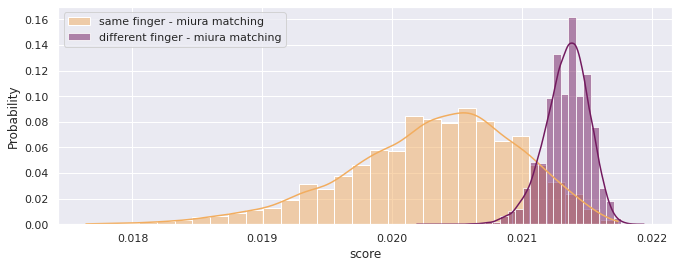

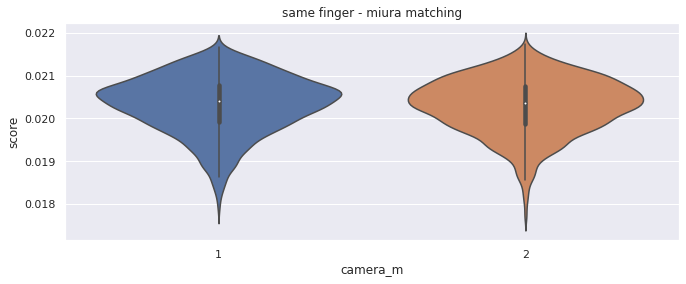

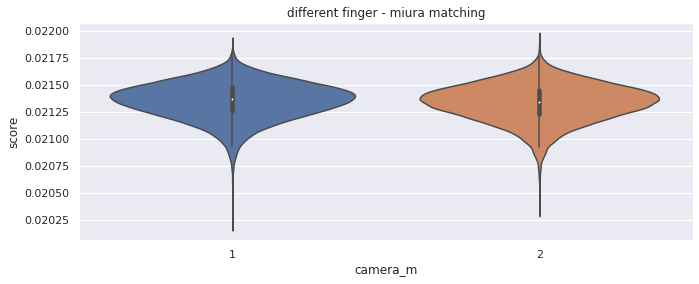

In [58]:
sns.set(style="darkgrid")

exp_id = num_to_roman(int(experiment_id.value))
experiment_path = "experiments/experiment_" + exp_id
print(experiment_path)
num_pop, colors, titles = read_metadata(experiment_path + "/metadata.txt")

#colors[5] = [0.1, 0.7, 0.3]

select = [False, True, False, True, False, False, False, False]

for i in range(num_pop):
    if select[i]:
        pop_id = num_to_roman(i + 1)
        df = pd.read_csv(experiment_path + "/population_" + pop_id + "/results.csv")
#         df = df[df["camera_m"] == 2]
        sns.histplot(data=df, x="score", stat="probability", color=colors[i], label=titles[i], kde=True, bins=30) #, ax=axs[2])
plt.legend()
plt.show()

for i in range(num_pop):
    if select[i]:
        pop_id = num_to_roman(i + 1)
        df = pd.read_csv(experiment_path + "/population_" + pop_id + "/results.csv")
        sns.violinplot(x=df["camera_m"], y=df["score"])
        plt.title(titles[i])
        plt.show()